In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
meddata = pd.read_csv("https://raw.githubusercontent.com/shailooz/AIBOOTCAMP2026/main/Day11/concrete_data.csv")
meddata.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
meddata.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


<Axes: xlabel='Age', ylabel='Strength'>

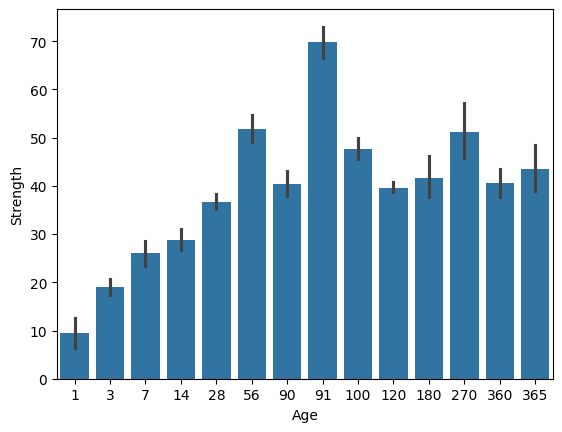

In [4]:
sns.barplot(x = 'Age', y ='Strength', data = meddata)

<Axes: xlabel='Age', ylabel='Strength'>

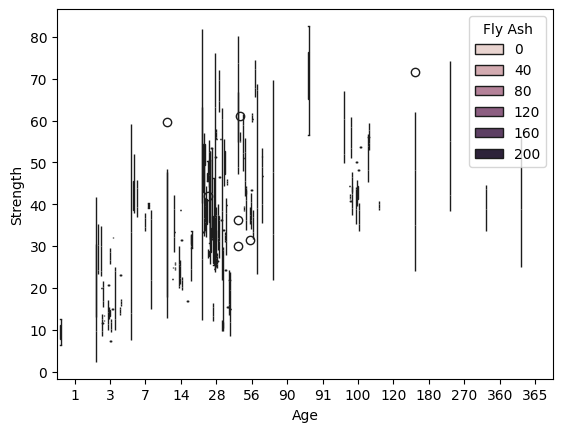

In [5]:
sns.boxplot(x= 'Age', y='Strength', hue='Fly Ash', data = meddata)

/tmp/ipykernel_1678/4105150574.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(meddata['Strength'], bins = 50)


<Axes: xlabel='Strength', ylabel='Density'>

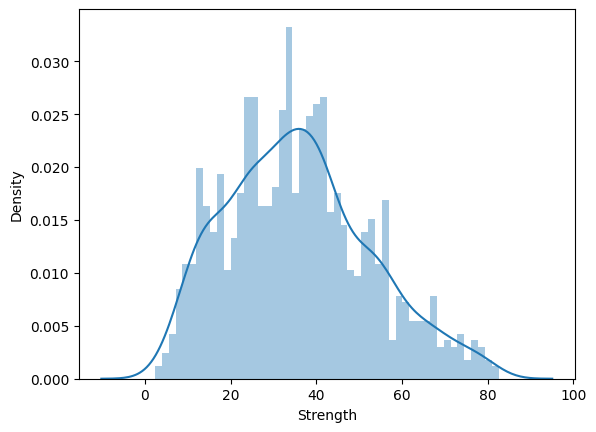

In [6]:
sns.distplot(meddata['Strength'], bins = 50)

In [7]:
X = meddata.iloc[:,:-1].values
y = meddata.iloc[:,-1].values

In [8]:
print(X)

[[ 540.     0.     0.  ... 1040.   676.    28. ]
 [ 540.     0.     0.  ... 1055.   676.    28. ]
 [ 332.5  142.5    0.  ...  932.   594.   270. ]
 ...
 [ 148.5  139.4  108.6 ...  892.4  780.    28. ]
 [ 159.1  186.7    0.  ...  989.6  788.9   28. ]
 [ 260.9  100.5   78.3 ...  864.5  761.5   28. ]]


In [9]:
print(y)

[79.99 61.89 40.27 ... 23.7  32.77 32.4 ]


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
tr_r2 = model.score(X_train,y_train)
print("Training R^2 = ",tr_r2)
ts_r2 = model.score(X_test,y_test)
print("Testing R^2 = ",ts_r2)

Training R^2 =  0.6105238047649741
Testing R^2 =  0.6275531792314851


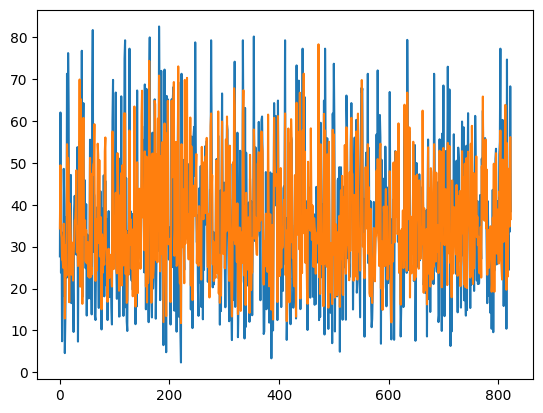

In [12]:
y_pred=model.predict(X_train)
plt.plot(y_train)
plt.plot(y_pred)
plt.show()

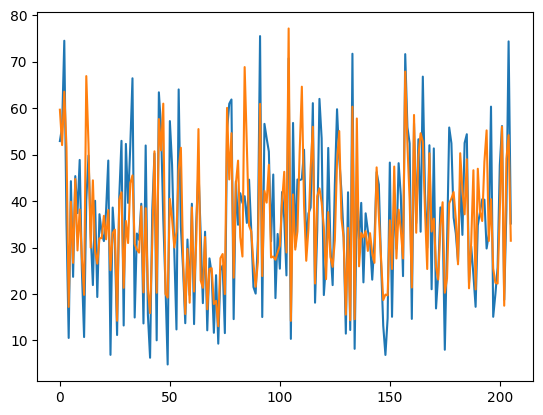

In [13]:
y_pred = model.predict(X_test)
plt.plot(y_test)
plt.plot(y_pred)
plt.show()

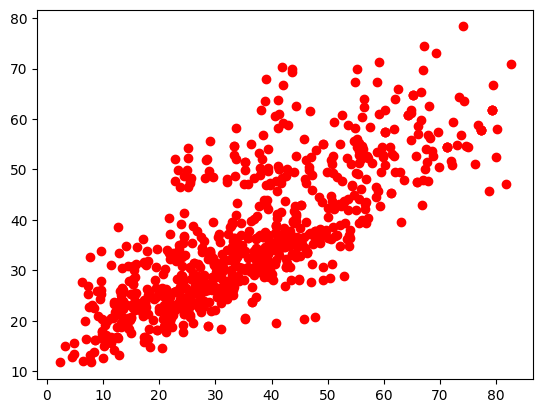

In [14]:
plt.scatter(y_train,model.predict(X_train),color = 'red')

In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)
tr_r2 = model.score(X_train,y_train)
print("Training R^2 = ",tr_r2)
ts_r2 = model.score(X_test,y_test)
print("Testing R^2 = ",ts_r2)

Training R^2 =  0.9857973439305057
Testing R^2 =  0.8743109389752077


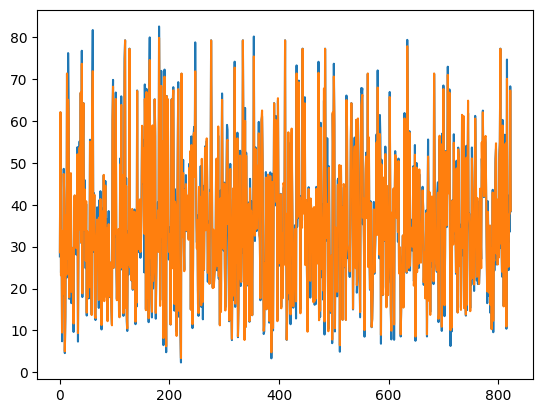

In [16]:
y_pred = model.predict(X_train)
plt.plot(y_train)
plt.plot(y_pred)
plt.show()

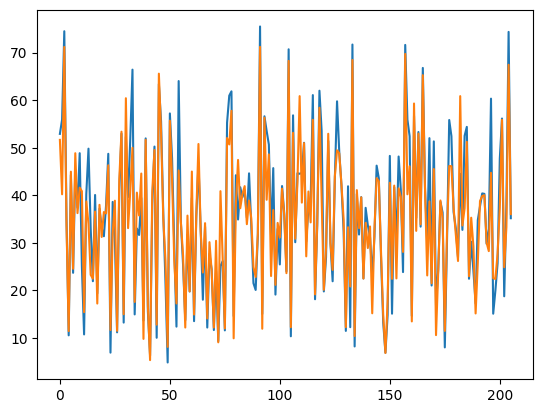

In [17]:
y_pred = model.predict(X_test)
plt.plot(y_test)
plt.plot(y_pred)
plt.show()

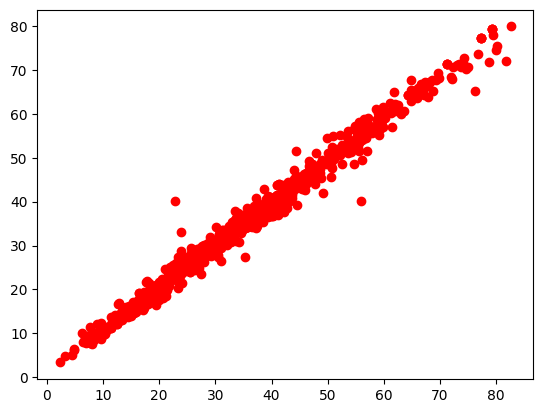

In [18]:
plt.scatter(y_train,model.predict(X_train),color = 'red')

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    tr_r2 = model.score(X_train, y_train)
    ts_r2 = model.score(X_test, y_test)
    results[name] = {'Training R^2': tr_r2, 'Testing R^2': ts_r2}

print("\n--- Model Comparison ---")
for name, scores in results.items():
    print(f"{name}:")
    print(f"  Training R^2 = {scores['Training R^2']:.4f}")
    print(f"  Testing R^2 = {scores['Testing R^2']:.4f}")

Training Linear Regression...
Training Random Forest Regressor...
Training Decision Tree Regressor...
Training Gradient Boosting Regressor...
Training Support Vector Regressor...
Training K-Nearest Neighbors Regressor...

--- Model Comparison ---
Linear Regression:
  Training R^2 = 0.6105
  Testing R^2 = 0.6276
Random Forest Regressor:
  Training R^2 = 0.9862
  Testing R^2 = 0.8841
Decision Tree Regressor:
  Training R^2 = 0.9969
  Testing R^2 = 0.8348
Gradient Boosting Regressor:
  Training R^2 = 0.9472
  Testing R^2 = 0.8829
Support Vector Regressor:
  Training R^2 = 0.2546
  Testing R^2 = 0.2320
K-Nearest Neighbors Regressor:
  Training R^2 = 0.7995
  Testing R^2 = 0.7330


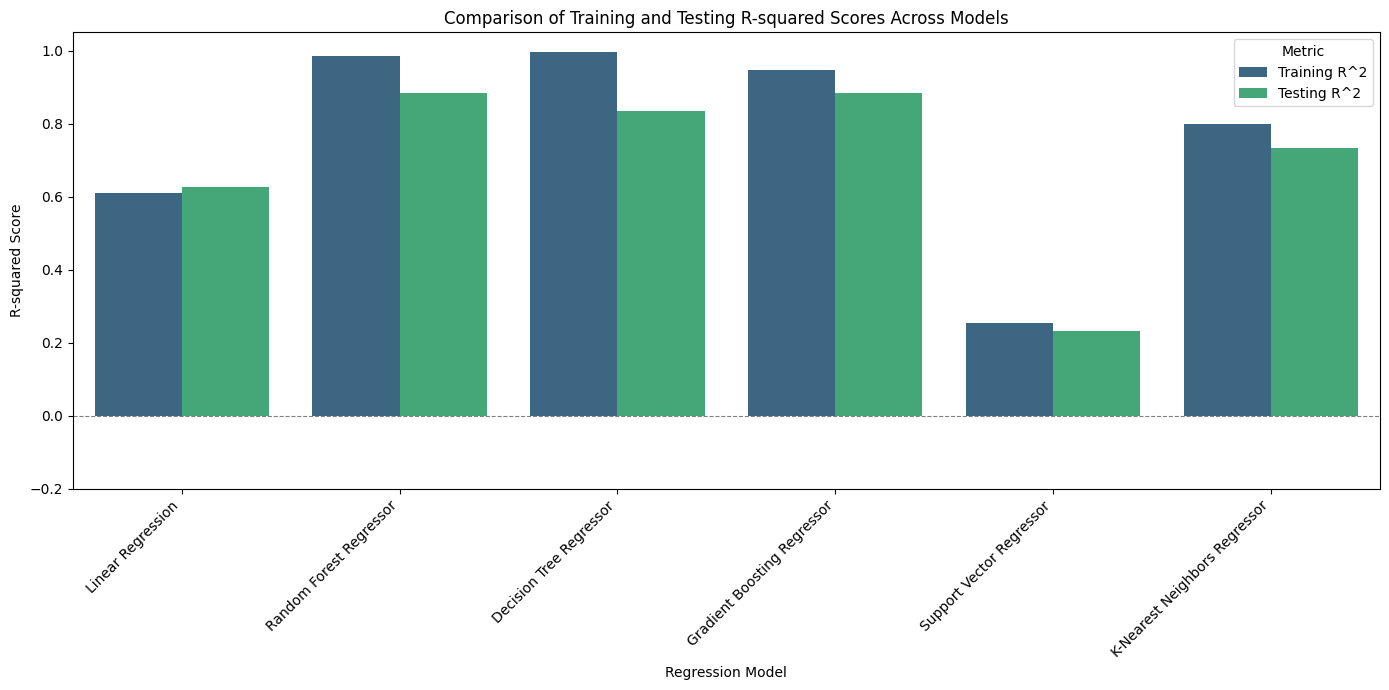

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results dictionary to a DataFrame for easier plotting
plot_data = []
for model_name, scores in results.items():
    plot_data.append({'Model': model_name, 'Metric': 'Training R^2', 'Score': scores['Training R^2']})
    plot_data.append({'Model': model_name, 'Metric': 'Testing R^2', 'Score': scores['Testing R^2']})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df, palette='viridis')
plt.title('Comparison of Training and Testing R-squared Scores Across Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(-0.2, 1.05) # Set y-axis limits to better visualize R^2 range
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a line at R^2 = 0
plt.legend(title='Metric')
plt.tight_layout()
plt.show()